<a href="https://colab.research.google.com/github/Rstam59/TaskDataRepoForStudents/blob/main/ASR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tarfile

with tarfile.open("/content/1774118365245-cv-corpus-25.0-2026-03-09-az.tar.gz", "r:gz") as tar:
    tar.extractall("common_voice_az")

/tmp/ipykernel_8387/2350319817.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("common_voice_az")


In [40]:
import os
import pandas as pd
from datasets import Dataset, Audio

DATA_DIR = "/content/common_voice_az/cv-corpus-25.0-2026-03-09/az"
CLIPS_DIR = f"{DATA_DIR}/clips"

df = pd.read_csv(f"{DATA_DIR}/train.tsv", sep="\t")

# choose 50 test samples
df = df.sample(50, random_state=42).copy()

# make full audio paths
df["audio"] = df["path"].apply(lambda x: os.path.join(CLIPS_DIR, x))

# keep only columns we need
df = df[["audio", "sentence"]]

dataset = Dataset.from_pandas(df)

# Hugging Face will decode/resample audio for you
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

dataset[0]

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x7d6bdc062690>,
 'sentence': 'Yer kürəsini başqa elmlər də öyrənir.',
 '__index_level_0__': 200}

In [45]:
sample = dataset[0]

audio_array = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]
text = sample["sentence"]

print(audio_array.shape)
print(sampling_rate)
print(text)

(61056,)
16000
Yer kürəsini başqa elmlər də öyrənir.


In [42]:
from IPython.display import Audio as IPythonAudio

IPythonAudio(audio_array, rate=sampling_rate)

In [7]:
!pip install -q gradio librosa

In [43]:
import gradio as gr

def generate_audio():
    example = dataset.shuffle(seed=None)[0]
    audio = example["audio"]

    return (
        audio["sampling_rate"],
        audio["array"],
    ), example["sentence"]


with gr.Blocks() as demo:
    gr.Markdown("## Common Voice Azerbaijani — Random Test Samples")

    with gr.Column():
        for _ in range(4):
            audio, sentence = generate_audio()
            gr.Audio(value=audio, label=sentence)

demo.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ae1af1dacf5aa594ff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://ae1af1dacf5aa594ff.gradio.live


Transcript: Həmin il Həbib də Leninqrad Dövlət Universitetinin Şərq fakültəsinin ərəb filologiyası bölməsinə daxil olur.
Sampling rate: 16000
Audio shape: (144576,)


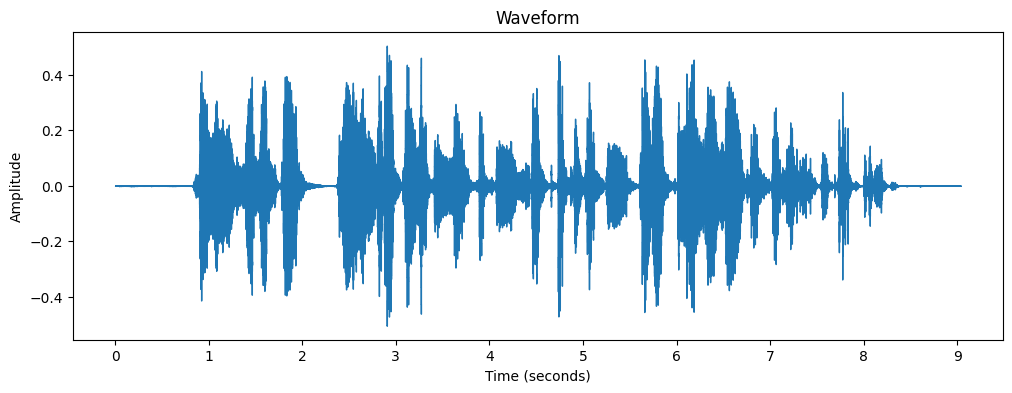

In [49]:
import librosa
import matplotlib.pyplot as plt

example = dataset[6]

array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]

print("Transcript:", example["sentence"])
print("Sampling rate:", sampling_rate)
print("Audio shape:", array.shape)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(array, sr=sampling_rate)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

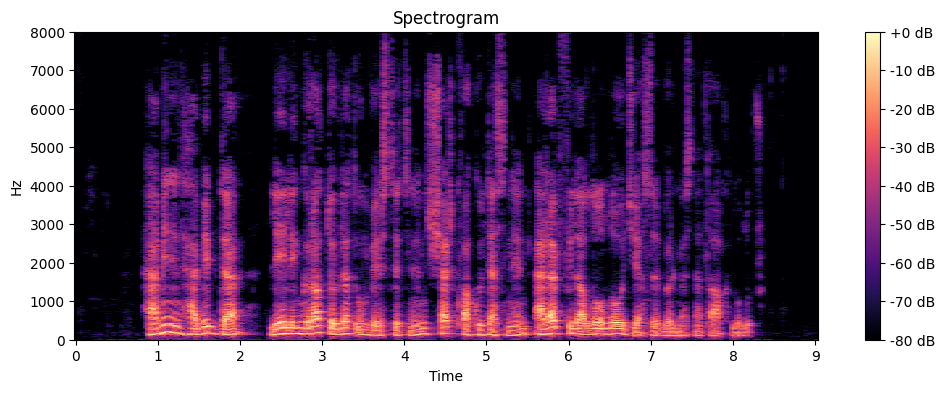

In [50]:
import numpy as np
import matplotlib.pyplot as plt


D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(
    S_db,
    sr=sampling_rate,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

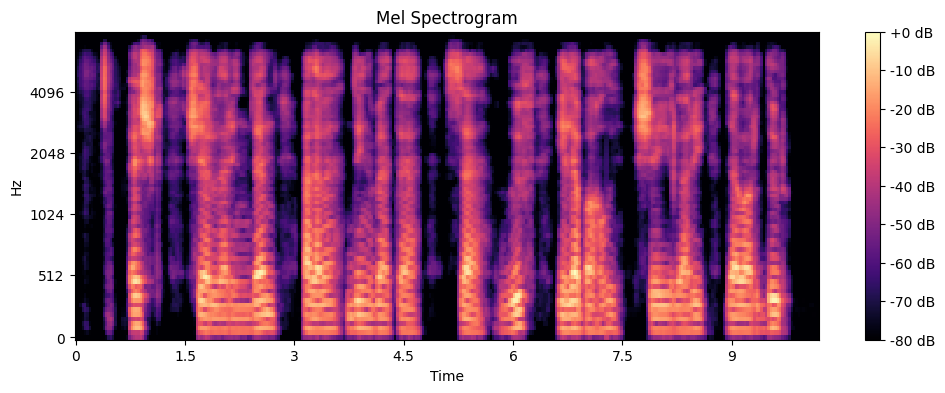

In [11]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

example = dataset[0]

array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]

mel = librosa.feature.melspectrogram(
    y=array,
    sr=sampling_rate,
    n_mels=80,
    fmax=8000
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(
    mel_db,
    sr=sampling_rate,
    x_axis="time",
    y_axis="mel",
    fmax=8000
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.show()

Index: 1
Transcript: Nəticədə aqrar sektorun məhsuldarlığı Azərbaycanın tarixində indiyədək bərabəri olmayan rekord göstəricilərinə çatmışdır.


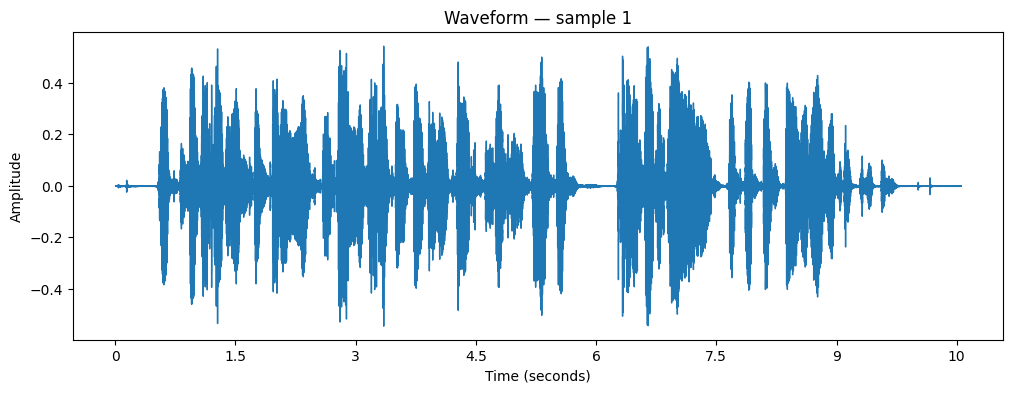

In [51]:
import random
from IPython.display import Audio as IPythonAudio, display

idx = random.randint(0, len(dataset) - 1)
example = dataset[idx]

array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]

print("Index:", idx)
print("Transcript:", example["sentence"])
display(IPythonAudio(array, rate=sampling_rate))

plt.figure(figsize=(12, 4))
librosa.display.waveshow(array, sr=sampling_rate)
plt.title(f"Waveform — sample {idx}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [13]:
!pip install -q transformers accelerate datasets evaluate jiwer librosa soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.5 MB/s eta 0:00:00


In [14]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = "openai/whisper-small"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = WhisperProcessor.from_pretrained(MODEL_NAME)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

model.eval()

print("Device:", device)

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Device: cuda


In [52]:
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="azerbaijani",
    task="transcribe"
)

In [53]:
predictions = []
references = []

for i, example in enumerate(dataset):
    audio = example["audio"]

    input_features = processor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).input_features.to(device)

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
        )

    pred_text = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    ref_text = example["sentence"]

    predictions.append(pred_text)
    references.append(ref_text)

    print(f"{i+1}/{len(dataset)}")
    print("REF :", ref_text)
    print("PRED:", pred_text)
    print("-" * 80)

1/50
REF : Yer kürəsini başqa elmlər də öyrənir.
PRED: Yer kürəsinin başqa elimlər də öyrənir.
--------------------------------------------------------------------------------
2/50
REF : Nəticədə aqrar sektorun məhsuldarlığı Azərbaycanın tarixində indiyədək bərabəri olmayan rekord göstəricilərinə çatmışdır.
PRED: Nəticədə agrar sektorun məhsul darlıqı Azərbaycanın tarixində indikək bərabəri olmayan rekor göstəricilərlə çatmışdır.
--------------------------------------------------------------------------------
3/50
REF : Adətən mütləq dərinliyinə görə ayrılır.
PRED: Hadətən mütləq dərinliyinə görə ayrılır.
--------------------------------------------------------------------------------
4/50
REF : Bir müddət sonra iki polis birlikdə axtarışa başlayır.
PRED: Bir müdə sonra iki polis birlikdə axtarışa başlayır.
--------------------------------------------------------------------------------
5/50
REF : Səsin əks olunmasından naviqasiya işlərində də istifadə olunur.
PRED: Səsin əks olunmazsı

In [54]:
import re

def normalize_text(text):
    text = text.lower().strip()

    # keep Azerbaijani letters, numbers, and spaces
    text = re.sub(r"[^\w\səıöüçğş]", " ", text)

    # normalize multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


norm_predictions = [normalize_text(x) for x in predictions]
norm_references = [normalize_text(x) for x in references]

In [55]:
import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

avg_wer = wer_metric.compute(
    predictions=norm_predictions,
    references=norm_references
)

avg_cer = cer_metric.compute(
    predictions=norm_predictions,
    references=norm_references
)

print(f"Average WER: {avg_wer * 100:.2f}%")
print(f"Average CER: {avg_cer * 100:.2f}%")

Average WER: 45.83%
Average CER: 12.09%


In [56]:
from jiwer import wer, cer
import pandas as pd

rows = []

for i, (ref, pred, norm_ref, norm_pred) in enumerate(
    zip(references, predictions, norm_references, norm_predictions)
):
    sample_wer = wer(norm_ref, norm_pred)
    sample_cer = cer(norm_ref, norm_pred)

    rows.append({
        "index": i,
        "reference": ref,
        "prediction": pred,
        "normalized_reference": norm_ref,
        "normalized_prediction": norm_pred,
        "wer_percent": sample_wer * 100,
        "cer_percent": sample_cer * 100,
    })

results_df = pd.DataFrame(rows)

results_df.head()

,index,reference,prediction,normalized_reference,normalized_prediction,wer_percent,cer_percent
0,0,Yer kürəsini başqa elmlər də öyrənir.,Yer kürəsinin başqa elimlər də öyrənir.,yer kürəsini başqa elmlər də öyrənir,yer kürəsinin başqa elimlər də öyrənir,33.333333,5.555556
1,1,Nəticədə aqrar sektorun məhsuldarlığı Azərbayc...,Nəticədə agrar sektorun məhsul darlıqı Azərbay...,nəticədə aqrar sektorun məhsuldarlığı azərbayc...,nəticədə agrar sektorun məhsul darlıqı azərbay...,50.000000,7.500000
2,2,Adətən mütləq dərinliyinə görə ayrılır.,Hadətən mütləq dərinliyinə görə ayrılır.,adətən mütləq dərinliyinə görə ayrılır,hadətən mütləq dərinliyinə görə ayrılır,20.000000,2.631579
3,3,Bir müddət sonra iki polis birlikdə axtarışa b...,Bir müdə sonra iki polis birlikdə axtarışa baş...,bir müddət sonra iki polis birlikdə axtarışa b...,bir müdə sonra iki polis birlikdə axtarışa baş...,12.500000,3.773585
4,4,Səsin əks olunmasından naviqasiya işlərində də...,Səsin əks olunmazsından nəbəqəs işlərin də də ...,səsin əks olunmasından naviqasiya işlərində də...,səsin əks olunmazsından nəbəqəs işlərin də də ...,62.500000,17.741935


In [57]:
best_5 = results_df.sort_values("wer_percent", ascending=True).head(5)

best_5[[
    "index",
    "wer_percent",
    "cer_percent",
    "reference",
    "prediction"
]]

,index,wer_percent,cer_percent,reference,prediction
7,7,0.000000,0.000000,Burada onun oğlu dünyaya gəlib.,Burada onun oğlu dünyaya gəlib.
9,9,9.090909,1.587302,Alətin alt hissəsində onu yerə qoymaq üçün iti...,Ağətin alt hissəsində onu yerə qoymaq üçün iti...
3,3,12.500000,3.773585,Bir müddət sonra iki polis birlikdə axtarışa b...,Bir müdə sonra iki polis birlikdə axtarışa baş...
33,33,15.384615,5.617978,Bu suları Laçın və ətraf rayonların əhalisi öz...,Bu suları Laçın və ətraf rayonların əhalisi öz...
48,48,16.666667,2.272727,Vəkil məhkəmə iclasında iştirak edə bilməyib.,Vəkil məhkəbə iclasında iştirak edə bilməyib.


In [58]:
worst_5 = results_df.sort_values("wer_percent", ascending=False).head(5)

worst_5[[
    "index",
    "wer_percent",
    "cer_percent",
    "reference",
    "prediction"
]]

,index,wer_percent,cer_percent,reference,prediction
40,40,100.000000,14.285714,Ramiz Məmmədov.,Ramizməm mədov.
38,38,100.000000,36.363636,Seçkilərin yekun nəticələri gələn həftə təsdiq...,Səndşilərin yetim nəktiyiyələri gəran əfətətis...
27,27,83.333333,22.916667,Belarus milli futbol komandasına namizəd sayılır.,Virlarus müirli futbol komandası namizə sahilir.
37,37,80.000000,24.242424,Qoruğun bitki örtüyü zəngin deyil.,Qorun bitki yörtüyü zəndcində il.
46,46,80.000000,10.344828,Abidə tunc dövrünə aid edilir.,Abi də tunç dövünə aid edilir.


In [59]:
print("Model: openai/whisper-small")
print(f"Number of samples: {len(results_df)}")
print(f"Average WER (%): {avg_wer * 100:.2f}")
print(f"Average CER (%): {avg_cer * 100:.2f}")

print("\nBest 5 examples:")
display(best_5[["index", "wer_percent", "cer_percent", "reference", "prediction"]])

print("\nWorst 5 examples:")
display(worst_5[["index", "wer_percent", "cer_percent", "reference", "prediction"]])

Model: openai/whisper-small
Number of samples: 50
Average WER (%): 45.83
Average CER (%): 12.09

Best 5 examples:


,index,wer_percent,cer_percent,reference,prediction
7,7,0.000000,0.000000,Burada onun oğlu dünyaya gəlib.,Burada onun oğlu dünyaya gəlib.
9,9,9.090909,1.587302,Alətin alt hissəsində onu yerə qoymaq üçün iti...,Ağətin alt hissəsində onu yerə qoymaq üçün iti...
3,3,12.500000,3.773585,Bir müddət sonra iki polis birlikdə axtarışa b...,Bir müdə sonra iki polis birlikdə axtarışa baş...
33,33,15.384615,5.617978,Bu suları Laçın və ətraf rayonların əhalisi öz...,Bu suları Laçın və ətraf rayonların əhalisi öz...
48,48,16.666667,2.272727,Vəkil məhkəmə iclasında iştirak edə bilməyib.,Vəkil məhkəbə iclasında iştirak edə bilməyib.



Worst 5 examples:


,index,wer_percent,cer_percent,reference,prediction
40,40,100.000000,14.285714,Ramiz Məmmədov.,Ramizməm mədov.
38,38,100.000000,36.363636,Seçkilərin yekun nəticələri gələn həftə təsdiq...,Səndşilərin yetim nəktiyiyələri gəran əfətətis...
27,27,83.333333,22.916667,Belarus milli futbol komandasına namizəd sayılır.,Virlarus müirli futbol komandası namizə sahilir.
37,37,80.000000,24.242424,Qoruğun bitki örtüyü zəngin deyil.,Qorun bitki yörtüyü zəndcində il.
46,46,80.000000,10.344828,Abidə tunc dövrünə aid edilir.,Abi də tunç dövünə aid edilir.


In [23]:
df = pd.read_csv(f"{DATA_DIR}/test.tsv", sep="\t")


df = df.copy()


df["audio"] = df["path"].apply(lambda x: os.path.join(CLIPS_DIR, x))

df = df[["audio", "sentence"]]

dataset = Dataset.from_pandas(df)


dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

full_dataset = dataset.shuffle(seed=42)

train_size = min(200, int(len(full_dataset) * 0.8))
eval_size = min(50, len(full_dataset) - train_size)

train_dataset = full_dataset.select(range(train_size))
eval_dataset = full_dataset.select(range(train_size, train_size + eval_size))

print(train_dataset)
print(eval_dataset)

Dataset({
    features: ['audio', 'sentence'],
    num_rows: 100
})
Dataset({
    features: ['audio', 'sentence'],
    num_rows: 26
})


In [30]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="azerbaijani",
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(device)

model.generation_config.language = "azerbaijani"
model.generation_config.task = "transcribe"
model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="azerbaijani",
    task="transcribe"
)

model.generation_config.suppress_tokens = []

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [31]:
def prepare_example(example):
    audio = example["audio"]

    example["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    example["labels"] = processor.tokenizer(
        example["sentence"]
    ).input_ids

    return example


train_dataset = train_dataset.map(
    prepare_example,
    remove_columns=train_dataset.column_names
)

eval_dataset = eval_dataset.map(
    prepare_example,
    remove_columns=eval_dataset.column_names
)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

KeyError: 'audio'

In [26]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List

@dataclass
class DataCollatorSpeechSeq2Seq:
    processor: Any

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        input_features = [
            {"input_features": f["input_features"]} for f in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": f["labels"]} for f in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch


data_collator = DataCollatorSpeechSeq2Seq(processor=processor)

In [27]:
import evaluate

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_texts = processor.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_texts = processor.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    pred_texts = [normalize_text(x) for x in pred_texts]
    label_texts = [normalize_text(x) for x in label_texts]

    wer = wer_metric.compute(
        predictions=pred_texts,
        references=label_texts
    )

    return {"wer": wer}

In [28]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/whisper-small-az-finetuned",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=2,

    learning_rate=1e-5,
    warmup_steps=10,

    max_steps=100,

    eval_strategy="steps",
    eval_steps=20,

    save_strategy="steps",
    save_steps=20,

    logging_steps=10,

    predict_with_generate=True,
    generation_max_length=128,

    fp16=torch.cuda.is_available(),

    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    report_to="none"
)

In [32]:
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss,Validation Loss,Wer
20,2.378092,1.350240,0.601036
40,1.048080,1.152124,0.528497
60,0.657771,1.105648,0.549223
80,0.479530,1.070196,0.554404
100,0.460982,1.063597,0.590674


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=100, training_loss=1.2962912702560425, metrics={'train_runtime': 504.1926, 'train_samples_per_second': 1.587, 'train_steps_per_second': 0.198, 'total_flos': 2.2278792904704e+17, 'train_loss': 1.2962912702560425, 'epoch': 7.72})

In [33]:
trainer.save_model("/content/whisper-small-az-finetuned")
processor.save_pretrained("/content/whisper-small-az-finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/whisper-small-az-finetuned/processor_config.json']

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)
logs.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_wer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,4.790441,45.171322,0.000009,0.80,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.378092,25.338264,0.000009,1.56,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.56,20,1.35024,0.601036,13.5263,1.922,0.518,NaN,NaN,NaN,NaN,NaN
3,1.330918,16.681099,0.000008,2.32,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.048080,16.888842,0.000007,3.08,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


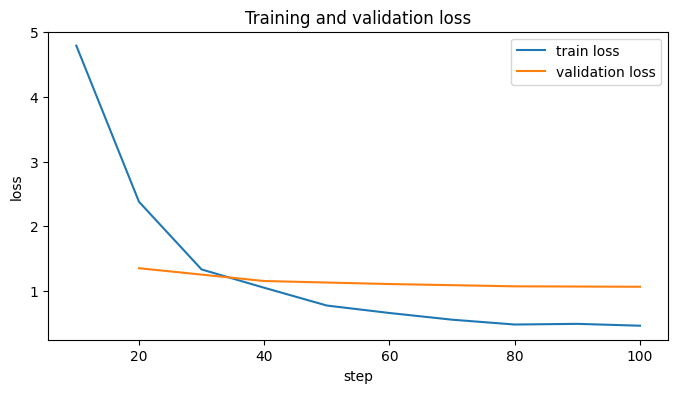

In [35]:
train_logs = logs[logs["loss"].notna()] if "loss" in logs else pd.DataFrame()
eval_logs = logs[logs["eval_loss"].notna()] if "eval_loss" in logs else pd.DataFrame()

plt.figure(figsize=(8, 4))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], label="train loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="validation loss")

plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

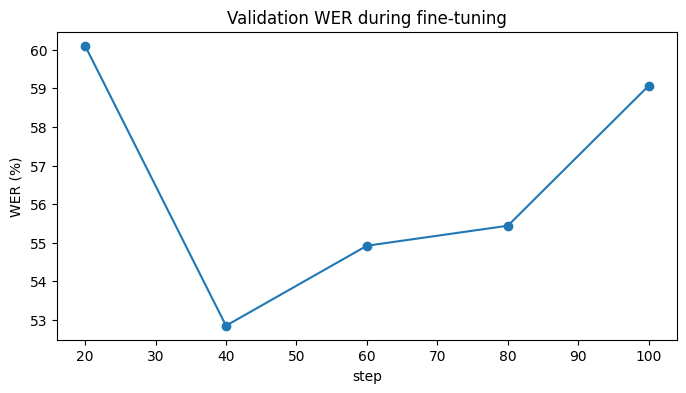

In [36]:
wer_logs = logs[logs["eval_wer"].notna()] if "eval_wer" in logs else pd.DataFrame()

plt.figure(figsize=(8, 4))
plt.plot(wer_logs["step"], wer_logs["eval_wer"] * 100, marker="o")
plt.xlabel("step")
plt.ylabel("WER (%)")
plt.title("Validation WER during fine-tuning")
plt.show()